In [1]:
import os
import shutil
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
import keras
import pandas as pd
from collections import deque

from tqdm import tqdm
import time

from IPython.display import HTML
from base64 import b64encode

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from keras.layers import *
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

import gc

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import cv2
import numpy as np
import os
from IPython.display import HTML, display
import random

USE_SEED = True

if USE_SEED:
    SEED = 42
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    os.environ['PYTHONHASHSEED'] = str(SEED)

2025-06-17 19:29:50.901510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750188591.120203      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750188591.186531      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
features_test = np.load('/kaggle/input/data-fp-deeplearning/features_test.npy')
features_train = np.load('/kaggle/input/data-fp-deeplearning/features_train-001.npy')
labels_test = np.load('/kaggle/input/data-fp-deeplearning/labels_test.npy')
labels_train = np.load('/kaggle/input/data-fp-deeplearning/labels_train.npy')
test_indices = np.load('/kaggle/input/data-fp-deeplearning/test_indices.npy')
video_files_paths = np.load('/kaggle/input/data-fp-deeplearning/video_files_paths.npy')

In [3]:
print(features_train.shape, features_test.shape)
print(labels_train.shape, labels_test.shape)

(3200, 16, 112, 112, 3) (800, 16, 112, 112, 3)
(3200, 2) (800, 2)


In [4]:
INITIAL_HEIGHT, INITIAL_WIDTH = 64, 64
FINAL_HEIGHT, FINAL_WIDTH = 112, 112
SEQUENCE_LENGTH = 16
CLASSES_LIST = ["NonViolence", "Violence"]

In [5]:
from tensorflow.keras.applications import EfficientNetV2S

efficientnet = EfficientNetV2S(include_top=False, weights='imagenet')
efficientnet.trainable=True

# for layer in efficientnet.layers[:-60]:
#     layer.trainable = False

I0000 00:00:1750188659.079007      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750188659.079663      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
len(efficientnet.layers)

513

## Building The Model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 16, 4, 4, 1280)      │      20,331,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 4, 4, 1280)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 16, 20480)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 16, 256)             │      21,103,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,938,306 (159.98 MB)

 Trainable params: 41,784,434 (159.39 MB)

 Non-trainable params: 153,872 (601.06 KB)

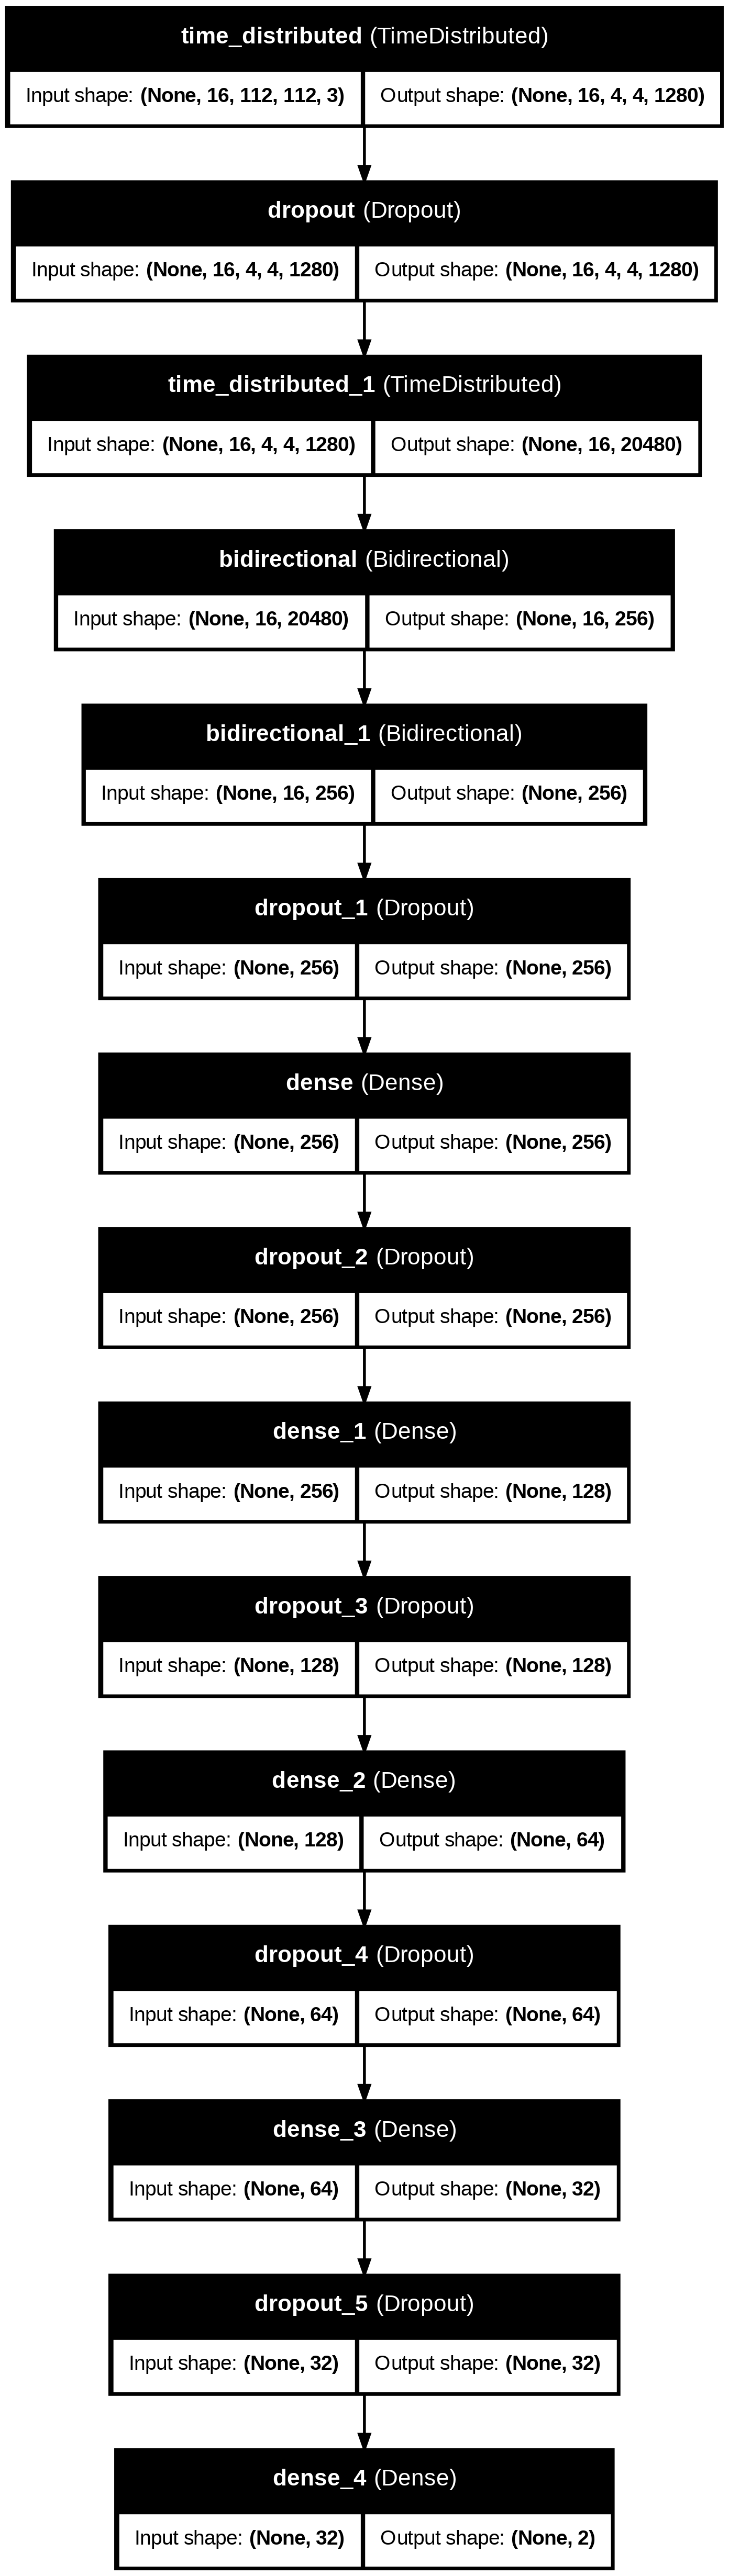

In [7]:
def create_model():
    model = Sequential()
    
    model.add(Input(shape=(SEQUENCE_LENGTH, FINAL_HEIGHT, FINAL_WIDTH, 3)))

    model.add(TimeDistributed(efficientnet))

    model.add(Dropout(0.25))

    model.add(TimeDistributed(Flatten()))
    

    model.add(Bidirectional(LSTM(128, return_sequences=True)))
    model.add(Bidirectional(LSTM(128)))

    model.add(Dropout(0.25))
    
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.25))
    
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.25))
    
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.25))
    
    model.add(Dense(len(CLASSES_LIST), activation='softmax'))  

    model.summary()
    return model

EffiBiLSTM_model = create_model()

plot_model(EffiBiLSTM_model, to_file='EffiBiLSTM_model_structure_plot.png', show_shapes=True, show_layer_names=True)

## Specifying Callbacks and Fitting

In [8]:
tf.debugging.set_log_device_placement(True)

early_stopping_callback = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                factor=0.6,
                                                patience=5,
                                                min_lr=0.00005,
                                                verbose=1)

EffiBiLSTM_model.compile(loss='categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                         metrics=["accuracy"])

EffiBiLSTM_model_history = EffiBiLSTM_model.fit(x=features_train, y=labels_train, epochs=100, batch_size=8,
                                            shuffle=True, validation_split=0.2, callbacks=[early_stopping_callback, reduce_lr])

Epoch 1/100


E0000 00:00:1750189370.173153      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/time_distributed_1/block1b_drop_29/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1750189488.860504      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


320/320 ━━━━━━━━━━━━━━━━━━━━ 1287s 1s/step - accuracy: 0.5445 - loss: 0.6839 - val_accuracy: 0.7937 - val_loss: 0.4589 - learning_rate: 1.0000e-04
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.7678 - loss: 0.5161 - val_accuracy: 0.6984 - val_loss: 0.6417 - learning_rate: 1.0000e-04
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.8842 - loss: 0.2973 - val_accuracy: 0.8000 - val_loss: 0.5182 - learning_rate: 1.0000e-04
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.9337 - loss: 0.2066 - val_accuracy: 0.7672 - val_loss: 0.9153 - learning_rate: 1.0000e-04
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 366s 1s/step - accuracy: 0.9566 - loss: 0.1555 - val_accuracy: 0.8219 - val_loss: 0.6842 - learning_rate: 1.0000e-04
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9711 - loss: 0.1166
Epoch 6: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-05.
320/320 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.971

In [9]:
model_evalution_history = EffiBiLSTM_model.evaluate(features_test, labels_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 149s 738ms/step - accuracy: 0.9168 - loss: 0.5211


In [10]:
# Save Model (ini upload ke github pas minggu terakhir aja yang hasil finalnya, taro di models/saved models)
EffiBiLSTM_model.save('EffiBiLSTM_model_softmax_categorical_sgd_4000data_v4.keras')

# Load Model
# model = keras.models.load_model('MoBiLSTM_model.keras')

In [11]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    epochs = range(len(metric_value_1))

    plt.plot(epochs, metric_value_1, 'blue', label=metric_name_1)
    plt.plot(epochs, metric_value_2, 'orange', label=metric_name_2)

    plt.title(str(plot_name))

    plt.legend()

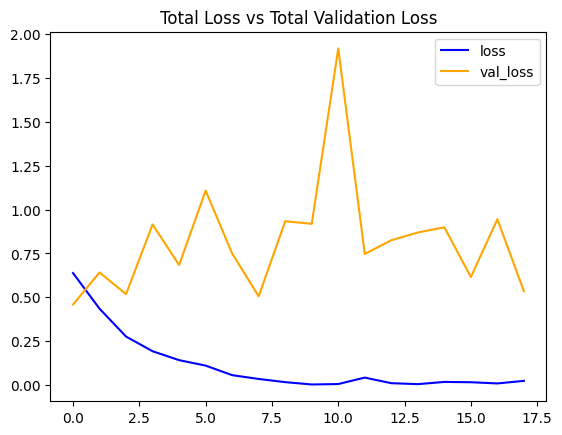

In [12]:
plot_metric(EffiBiLSTM_model_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

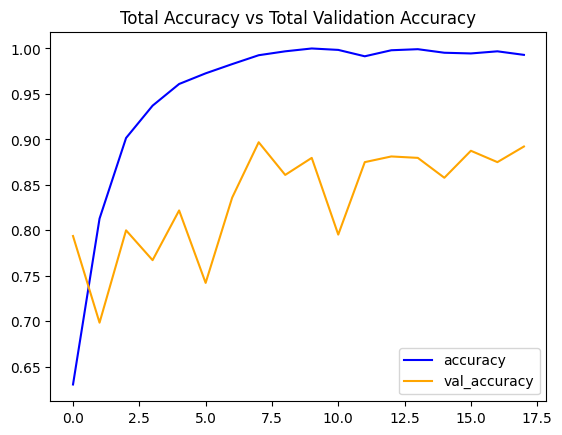

In [13]:
plot_metric(EffiBiLSTM_model_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

## Predicting Test Set

In [14]:
labels_predict = EffiBiLSTM_model.predict(features_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 131s 740ms/step


In [15]:
# Decoding the data to use in Metrics
labels_predict = np.argmax(labels_predict , axis=1)
labels_test_normal = np.argmax(labels_test , axis=1)

In [16]:
labels_test_normal.shape , labels_predict.shape

((800,), (800,))

In [17]:
from sklearn.metrics import accuracy_score
AccScore = accuracy_score(labels_predict, labels_test_normal)
print('Accuracy Score is : ', AccScore)

Accuracy Score is :  0.90625


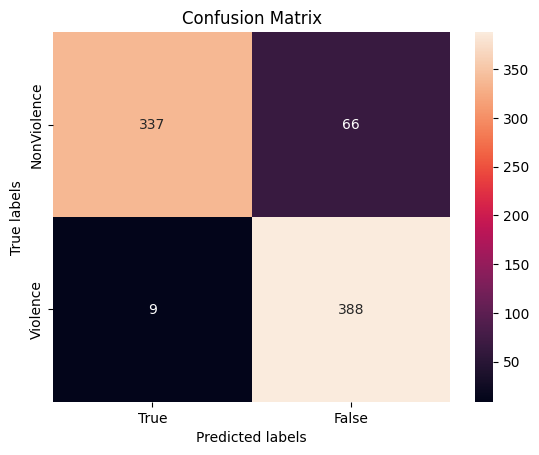

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

ax= plt.subplot()
cm=confusion_matrix(labels_test_normal, labels_predict)
sns.heatmap(cm, annot=True, fmt='g', ax=ax);

ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['True', 'False']); ax.yaxis.set_ticklabels(['NonViolence', 'Violence']);

In [19]:
from sklearn.metrics import classification_report

ClassificationReport = classification_report(labels_test_normal,labels_predict)
print('Classification Report is : \n', ClassificationReport)

Classification Report is : 
               precision    recall  f1-score   support

           0       0.97      0.84      0.90       403
           1       0.85      0.98      0.91       397

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



## Prediction Frame by Frame

In [20]:
# **1. Frame-by-Frame Prediction with Video Display**

def predict_single_video_with_frames(video_path, model, sequence_length=16):
    """
    Predict violence for a single video and return frame-by-frame analysis
    """
    # Extract frames from video
    video_frames = get_video_frames(video_path)
    if video_frames is None:
        return None, None, None

    # Preprocess for prediction
    processed_frames = preprocess_test_frames(video_frames)
    processed_frames = np.expand_dims(processed_frames, axis=0)  # Add batch dimension

    # Get prediction
    prediction = model.predict(processed_frames, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    # Get original frames for display (resize for visualization)
    display_frames = []
    for frame in video_frames:
        # Convert back to uint8 for display
        if frame.dtype == np.float32:
            display_frame = (frame * 255).astype(np.uint8)
        else:
            display_frame = frame
        # Resize for better display
        display_frame = cv2.resize(display_frame, (224, 224))
        display_frames.append(display_frame)

    return display_frames, predicted_class, confidence

def display_video_frames_with_prediction(frames, predicted_class, confidence, title="Video Analysis"):
    """
    Display video frames in a grid with prediction results
    """
    class_names = ["NonViolence", "Violence"]

    # Create figure
    fig, axes = plt.subplots(3, 6, figsize=(20, 12))
    fig.suptitle(f'{title}\nPrediction: {class_names[predicted_class]} (Confidence: {confidence:.3f})',
                 fontsize=16, fontweight='bold')

    # Display first 18 frames (3x6 grid)
    for i in range(18):
        row = i // 6
        col = i % 6

        if i < len(frames):
            # Convert BGR to RGB for matplotlib
            frame_rgb = cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(frame_rgb)
            axes[row, col].set_title(f'Frame {i+1}', fontsize=10)

            # Add colored border based on prediction
            if predicted_class == 1:  # Violence
                rect = patches.Rectangle((0, 0), frame_rgb.shape[1]-1, frame_rgb.shape[0]-1,
                                       linewidth=3, edgecolor='red', facecolor='none')
            else:  # NonViolence
                rect = patches.Rectangle((0, 0), frame_rgb.shape[1]-1, frame_rgb.shape[0]-1,
                                       linewidth=3, edgecolor='green', facecolor='none')
            axes[row, col].add_patch(rect)
        else:
            axes[row, col].axis('off')

        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

def Play_Video(filepath):
    html = ''
    video = open(filepath,'rb').read()
    src = 'data:video/mp4;base64,' + b64encode(video).decode()
    html += '<video width=640 muted controls autoplay loop><source src="%s" type="video/mp4"></video>' % src
    return HTML(html)


# **2. Test on Random Videos from Test Set** - Modified version with video playback

def test_random_videos_from_testset(model, features_test, labels_test, video_files_paths, test_indices, n_videos=4):
    """
    Test model on random videos from test set and display results
    """
    class_names = ["NonViolence", "Violence"]

    # Get random indices from test set
    random_test_indices = random.sample(list(range(len(features_test))), min(n_videos, len(features_test)))

    for i, test_idx in enumerate(random_test_indices):
        print(f"\n{'='*60}")
        print(f"VIDEO {i+1}/{len(random_test_indices)}")
        print(f"{'='*60}")

        # Get video info
        original_idx = test_indices[test_idx]
        video_path = video_files_paths[original_idx]
        true_label = np.argmax(labels_test[test_idx])

        print(f"Video Path: {video_path}")
        print(f"True Label: {class_names[true_label]}")

        # Play the original video
        print("\nOriginal Video:")
        display(Play_Video(video_path))

        # Make prediction
        test_sample = np.expand_dims(features_test[test_idx], axis=0)
        prediction = model.predict(test_sample, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = np.max(prediction[0])

        print(f"\nPredicted Label: {class_names[predicted_class]}")
        print(f"Confidence: {confidence:.4f}")
        print(f"Correct: {'✓' if predicted_class == true_label else '✗'}")

        # Display video frames with prediction
        frames, _, _ = predict_single_video_with_frames(video_path, model)
        if frames is not None:
            title = f"Video {i+1}: {os.path.basename(video_path)}"
            display_video_frames_with_prediction(frames, predicted_class, confidence, title)

In [21]:
def get_sampling_rate(video_path):
    """Determine sampling rate based on video duration"""
    video_reader = None
    try:
        video_reader = cv2.VideoCapture(video_path)
        if not video_reader.isOpened():
            raise IOError(f"Cannot open video file: {video_path}")

        fps = video_reader.get(cv2.CAP_PROP_FPS)
        frame_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = frame_count / fps if fps > 0 else 0

        return 10 if duration <= 30 else 5  # 10 FPS for videos ≤30s, 5 FPS for >30s
    except Exception as e:
        print(f"Error processing {video_path}: {str(e)}", file=sys.stderr)
        return None
    finally:
        if video_reader is not None:
            video_reader.release()

def get_video_frames(video_file):
    """Retrieve and process video frames with uniform sampling - Memory optimized"""
    video_capture = None
    try:
        extracted_frames = []
        video_capture = cv2.VideoCapture(video_file)

        if not video_capture.isOpened():
            raise IOError(f"Cannot open video file: {video_file}")

        # Obtain video properties
        frame_rate = video_capture.get(cv2.CAP_PROP_FPS)
        total_video_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
        video_duration = total_video_frames / frame_rate if frame_rate > 0 else 0

        sampling_freq = get_sampling_rate(video_file)
        if sampling_freq is None:
            return None

        target_frame_count = min(int(video_duration * sampling_freq), SEQUENCE_LENGTH)

        # Calculate uniform sampling interval
        sampling_interval = max(int(total_video_frames / target_frame_count), 1)

        # Collect frames at regular intervals
        for i in range(target_frame_count):
            # Position to the appropriate frame
            video_capture.set(cv2.CAP_PROP_POS_FRAMES, i * sampling_interval)

            # Retrieve the frame
            ret, frame_data = video_capture.read()

            if not ret:
                break

            # Resize immediately to save memory
            frame_resized = cv2.resize(frame_data, (INITIAL_WIDTH, INITIAL_HEIGHT))
            # Normalize and convert to float32 (more memory efficient than float64)
            normalized_data = frame_resized.astype(np.float32) / 255.0

            extracted_frames.append(normalized_data)

            # Clear frame_data from memory
            del frame_data, frame_resized

        # Pad with zeros if needed
        if len(extracted_frames) < SEQUENCE_LENGTH:
            zero_frame = np.zeros((INITIAL_HEIGHT, INITIAL_WIDTH, 3), dtype=np.float32)
            while len(extracted_frames) < SEQUENCE_LENGTH:
                extracted_frames.append(zero_frame.copy())

        return np.array(extracted_frames, dtype=np.float32)

    except Exception as e:
        print(f"Error processing frames from {video_file}: {str(e)}", file=sys.stderr)
        return None
    finally:
        if video_capture is not None:
            video_capture.release()

def preprocess_test_frames(frames):
    """Only resize and normalize without augmentation"""
    processed_frames = []
    for frame in frames:
        if frame.shape[:2] != (FINAL_HEIGHT, FINAL_WIDTH):
            resized_frame = cv2.resize(frame, (FINAL_WIDTH, FINAL_HEIGHT))
        else:
            resized_frame = frame
        processed_frames.append(resized_frame.astype(np.float32))

    return np.array(processed_frames, dtype=np.float32)


1️⃣ TESTING RANDOM VIDEOS FROM TEST SET

VIDEO 1/2
Video Path: ../input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_578.mp4
True Label: NonViolence

Original Video:



Predicted Label: Violence
Confidence: 0.9993
Correct: ✗


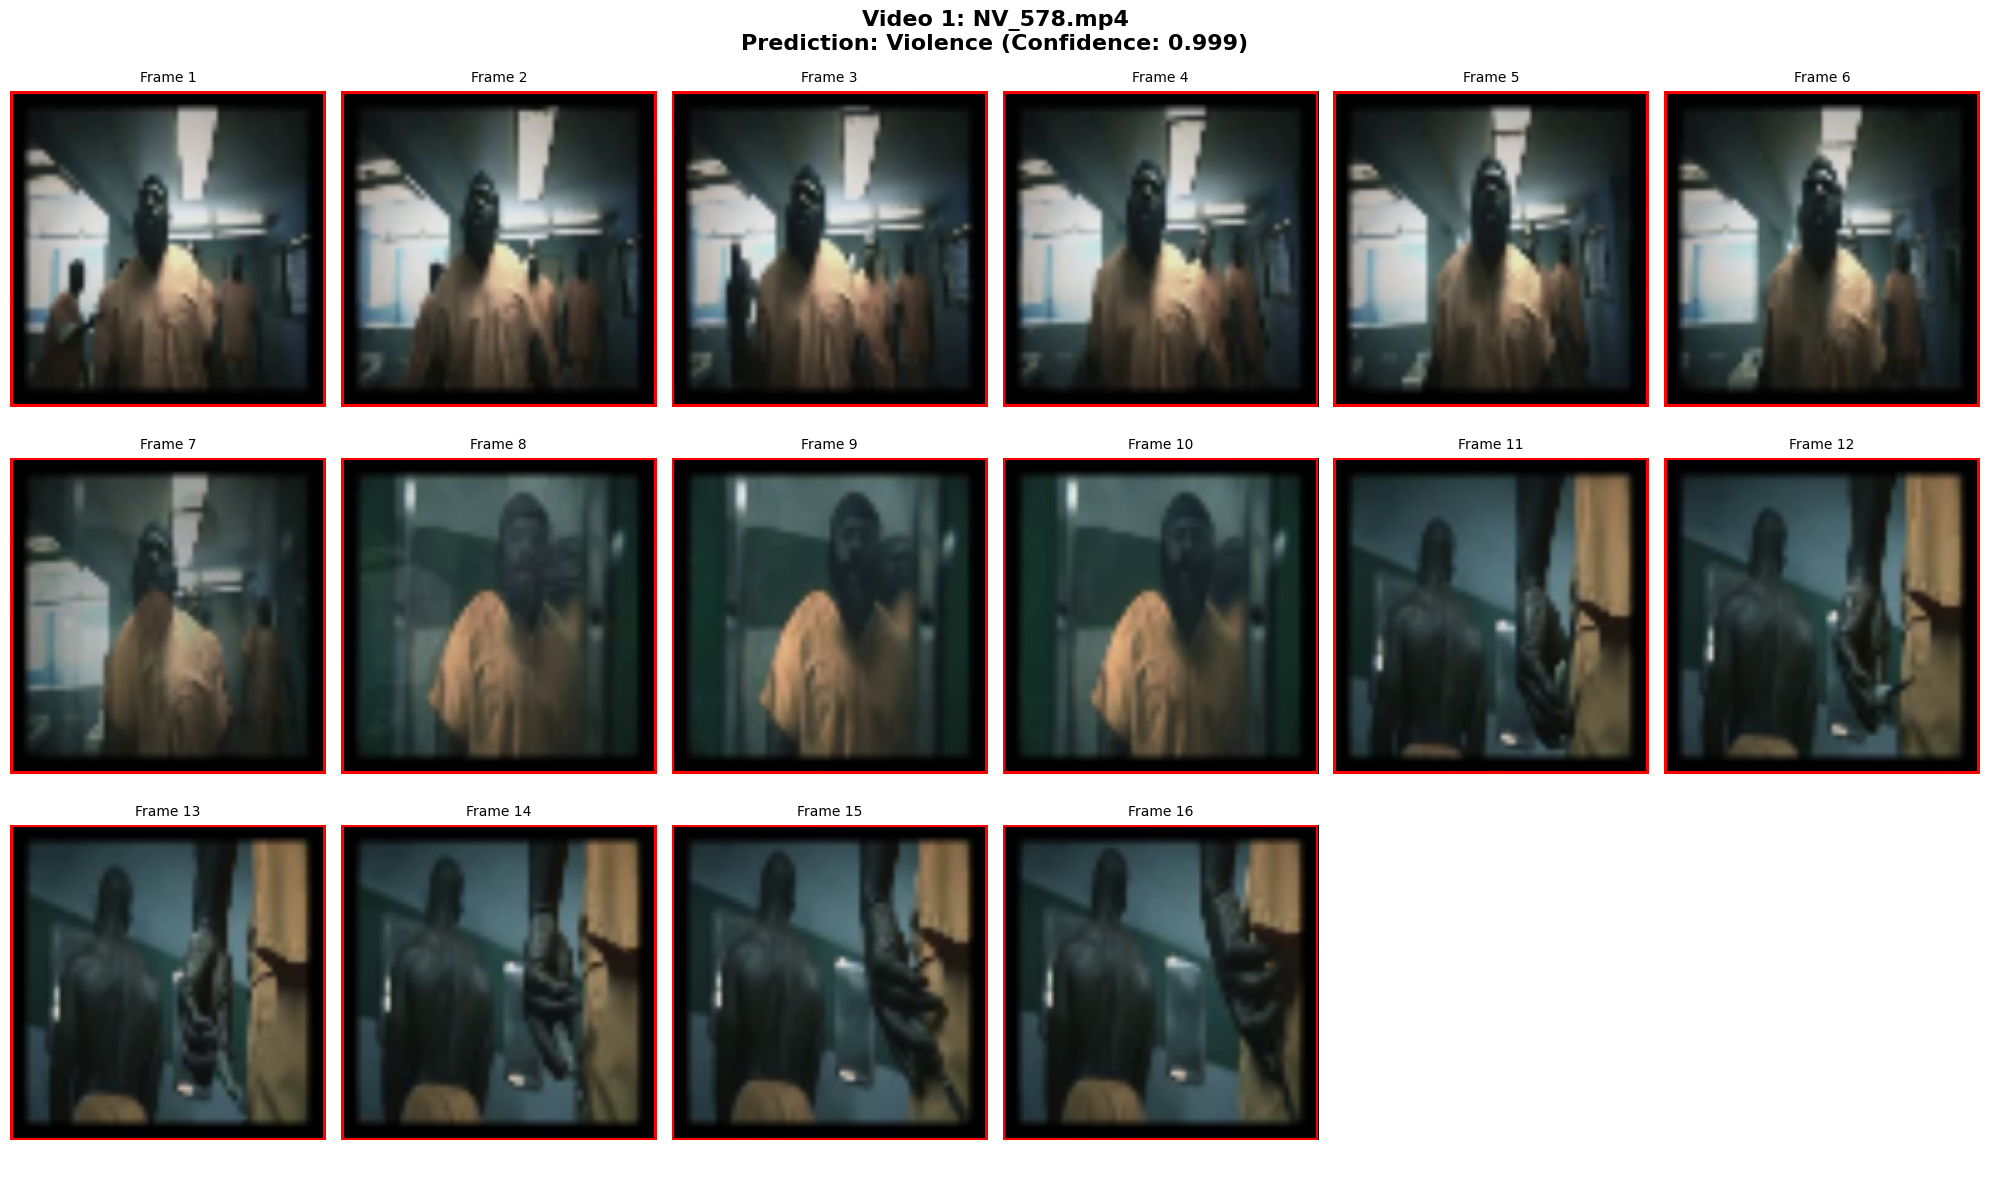


VIDEO 2/2
Video Path: ../input/harvard-violence-detection/Violence/v_d_b_57.mp4
True Label: Violence

Original Video:


FileNotFoundError: [Errno 2] No such file or directory: '../input/harvard-violence-detection/Violence/v_d_b_57.mp4'

In [22]:
print("\n1️⃣ TESTING RANDOM VIDEOS FROM TEST SET")
test_random_videos_from_testset(EffiBiLSTM_model, features_test, labels_test,
                               video_files_paths, test_indices, n_videos=2)